# Analyzing Quartz Solar Forecasts with DuckDB

This notebook demonstrates how to efficiently query and analyze forecast data using DuckDB.

In [1]:
# Install dependencies if needed
!pip install duckdb pandas matplotlib pyarrow fastparquet

In [2]:
from scripts.duck_db_utils import ForecastAnalyzer, quick_analysis
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

%matplotlib inline

In [3]:
from pathlib import Path

FORECAST_DIR = '../csv_forecasts'  
for file in Path(FORECAST_DIR).glob("*.csv"):
    if file.name == "multi_site_pv_forecasts.csv":
        print(file.name)
        temp_df = pd.read_csv(file, nrows=1)
        temp_df = temp_df.rename(columns ={
            'Unnamed: 0' : 'timestamp',
        })
        temp_df = temp_df.rename(columns=lambda x: x.strip().lower())
        print(temp_df.columns.tolist())


multi_site_pv_forecasts.csv
['timestamp', 'site1_latitude', 'site1_longitude', 'site1_capacity', 'site1 power', 'site2_latitude', 'site2_longitude', 'site2_capacity', 'site2 power']


## Example 1: Quick Analysis

Get an overview of all forecast data with a single function:

In [4]:
results = quick_analysis(FORECAST_DIR)
print(results)
print("\nColumns:", results.columns.tolist() if hasattr(results, 'columns') else "N/A")

FORECAST ANALYSIS SUMMARY

Daily Summary (Last 5 days):
        date  count_rows  avg_power_kw  peak_power_kw  total_energy_kwh
0 2023-11-01          96      0.220994       1.007783         21.215417
1 2023-11-02          96      0.291666       1.428812         27.999954

Hourly Profile (Daylight Hours):
    hour_of_day  sample_count  avg_power_kw       p25       p50       p75  \
7             7             8      0.024553  0.007427  0.018403  0.035939   
8             8             8      0.144890  0.071085  0.129389  0.214039   
9             9             8      0.379801  0.297597  0.367544  0.446429   
10           10             8      0.471270  0.405587  0.456395  0.515865   
11           11             8      0.512121  0.477680  0.505534  0.545806   
12           12             8      0.558547  0.445769  0.562024  0.646931   
13           13             8      0.485721  0.377565  0.473016  0.589344   
14           14             8      0.339267  0.288713  0.324108  0.373173   
1

## Example 2: Daily Summary Analysis

Aggregate forecasts by day across all files:

        date  count_rows  avg_power_kw  peak_power_kw  total_energy_kwh
0 2023-11-01          96      0.220994       1.007783         21.215417


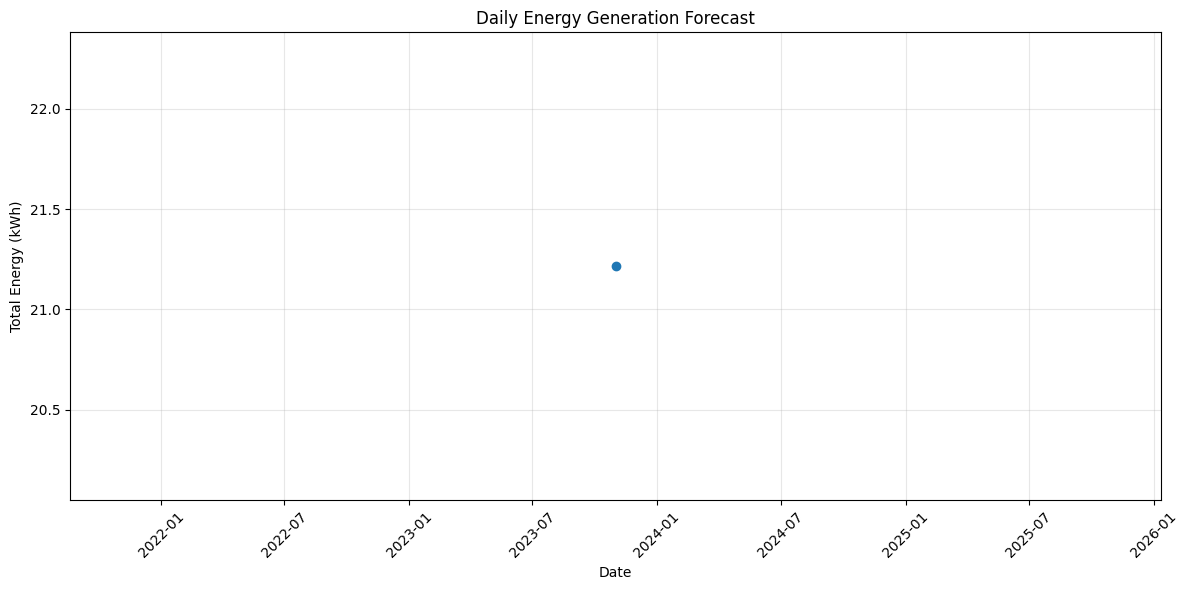

In [5]:
with ForecastAnalyzer(FORECAST_DIR) as analyzer:
    daily = analyzer.daily_summary(
        start_date='2023-11-01',
        end_date='2023-11-02'
    )

print(daily.head(10))

plt.figure(figsize=(12, 6))
plt.plot(daily['date'], daily['total_energy_kwh'], marker='o')
plt.xlabel('Date')
plt.ylabel('Total Energy (kWh)')
plt.title('Daily Energy Generation Forecast')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Example 3: Hourly Generation Profile

Understand typical generation patterns by hour of day:

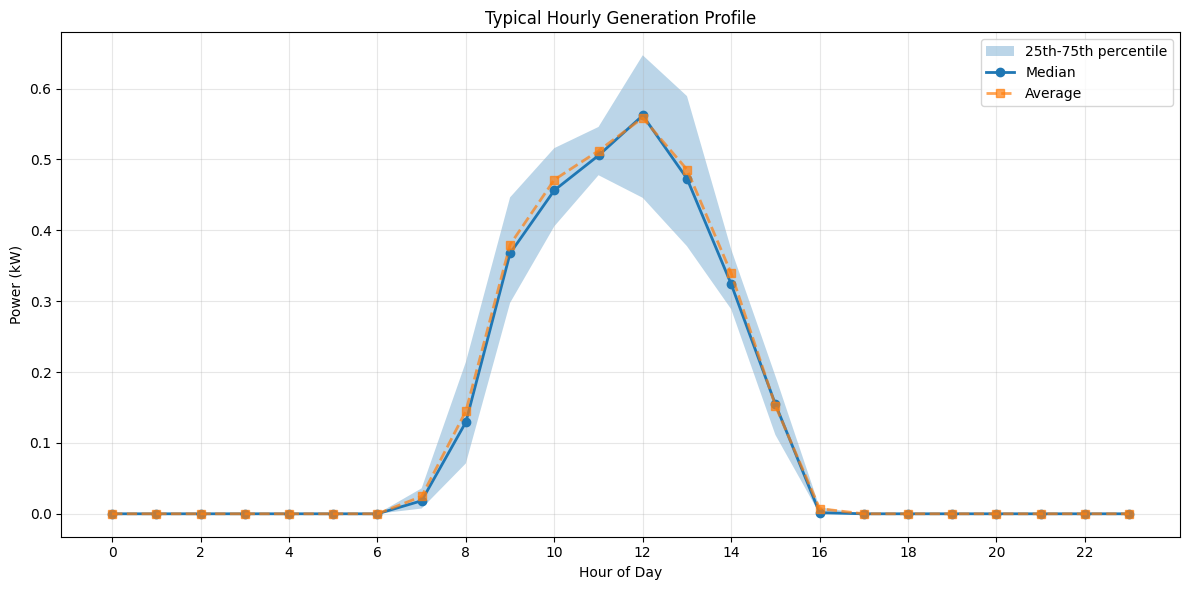

In [6]:
with ForecastAnalyzer(FORECAST_DIR) as analyzer:
    hourly = analyzer.hourly_profile()

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(hourly['hour_of_day'], hourly['p25'], hourly['p75'], alpha=0.3, label='25th-75th percentile')
ax.plot(hourly['hour_of_day'], hourly['p50'], 'o-', label='Median', linewidth=2)
ax.plot(hourly['hour_of_day'], hourly['avg_power_kw'], 's--', label='Average', linewidth=2, alpha=0.7)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Power (kW)')
ax.set_title('Typical Hourly Generation Profile')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

## Example 4: Multi-Site Comparison

  site_name  total_forecasts  avg_power_kw  peak_power_kw  total_energy_kwh  \
0     Site1              192      0.073759       0.396013         14.161769   
1     Site2              192      0.054406       0.318483         10.445917   

  first_forecast       last_forecast  
0     2023-11-01 2023-11-02 23:45:00  
1     2023-11-01 2023-11-02 23:45:00  


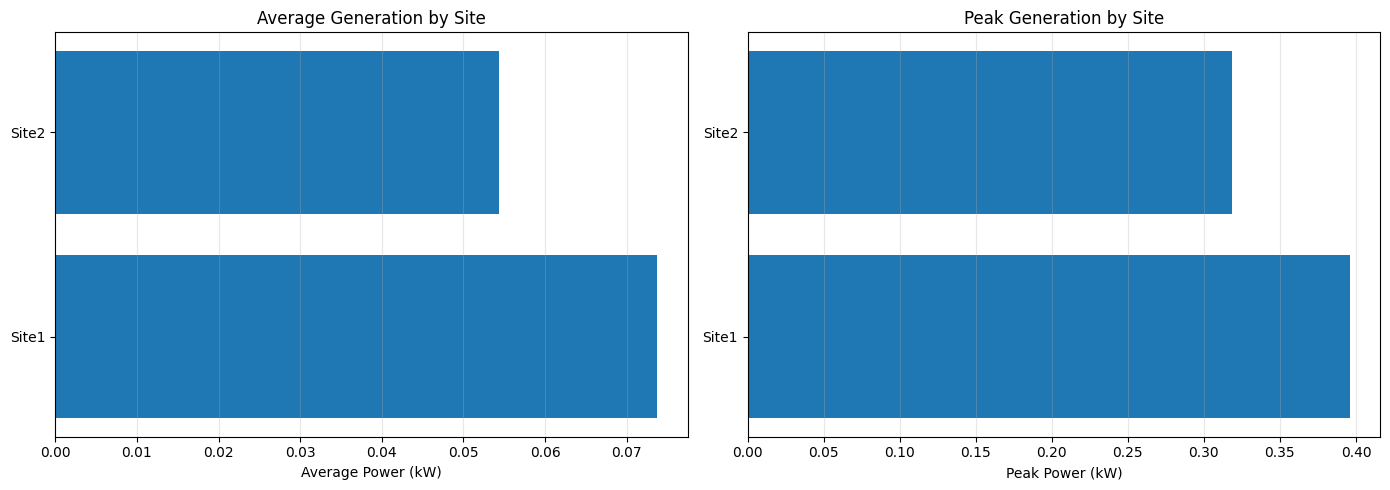

In [7]:
with ForecastAnalyzer(FORECAST_DIR) as analyzer:
    comparison = analyzer.site_comparison()

print(comparison)

if len(comparison) > 1:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.barh(comparison['site_name'], comparison['avg_power_kw'])
    ax1.set_xlabel('Average Power (kW)')
    ax1.set_title('Average Generation by Site')
    ax1.grid(True, alpha=0.3, axis='x')

    ax2.barh(comparison['site_name'], comparison['peak_power_kw'])
    ax2.set_xlabel('Peak Power (kW)')
    ax2.set_title('Peak Generation by Site')
    ax2.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

## Example 5: Custom SQL Queries

In [8]:
with ForecastAnalyzer(FORECAST_DIR) as a:
    print(a.con.execute("DESCRIBE forecasts").fetchdf())
    
with ForecastAnalyzer(FORECAST_DIR) as analyzer:
    print(analyzer.get_schema())
    peak_hours = analyzer.query("""
        SELECT timestamp, total_power_kw
        FROM forecasts
        WHERE total_power_kw > 0
        ORDER BY total_power_kw DESC
        LIMIT 20
    """)

print("Top 20 Peak Generation Periods:")
print(peak_hours)

      column_name column_type null   key default extra
0       timestamp   TIMESTAMP  YES  None    None  None
1  total_power_kw      DOUBLE  YES  None    None  None
2     site1_power      DOUBLE  YES  None    None  None
3     site2_power      DOUBLE  YES  None    None  None
      column_name column_type null   key default extra
0       timestamp   TIMESTAMP  YES  None    None  None
1  total_power_kw      DOUBLE  YES  None    None  None
2     site1_power      DOUBLE  YES  None    None  None
3     site2_power      DOUBLE  YES  None    None  None
Top 20 Peak Generation Periods:
             timestamp  total_power_kw
0  2023-11-02 13:00:00        0.714406
1  2023-11-02 12:45:00        0.708006
2  2023-11-02 12:30:00        0.692557
3  2023-11-02 13:15:00        0.650727
4  2023-11-02 11:45:00        0.635432
5  2023-11-02 11:30:00        0.634169
6  2023-11-02 12:00:00        0.631723
7  2023-11-02 12:15:00        0.623055
8  2023-11-02 10:15:00        0.612850
9  2023-11-02 10:00:00      

## Example 6: Rolling Averages

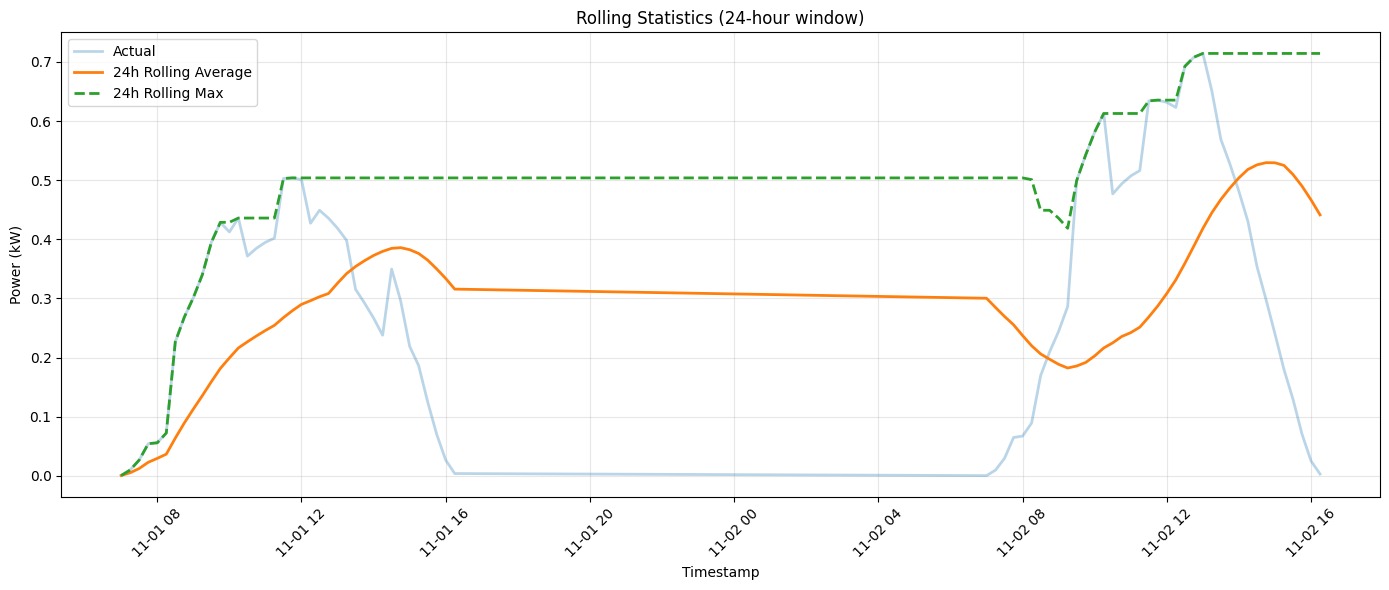

In [9]:
with ForecastAnalyzer(FORECAST_DIR) as analyzer:
    rolling = analyzer.query("""
        SELECT 
            timestamp, 
            total_power_kw,
            AVG(total_power_kw) OVER (ORDER BY timestamp ROWS BETWEEN 23 PRECEDING AND CURRENT ROW) AS rolling_24h_avg,
            MAX(total_power_kw) OVER (ORDER BY timestamp ROWS BETWEEN 23 PRECEDING AND CURRENT ROW) AS rolling_24h_max
        FROM forecasts
        WHERE total_power_kw > 0
        ORDER BY timestamp
    """)

plt.figure(figsize=(14, 6))
plt.plot(rolling['timestamp'], rolling['total_power_kw'], alpha=0.3, label='Actual', linewidth=2)
plt.plot(rolling['timestamp'], rolling['rolling_24h_avg'], label='24h Rolling Average', linewidth=2)
plt.plot(rolling['timestamp'], rolling['rolling_24h_max'], label='24h Rolling Max', linewidth=2, linestyle='--')
plt.xlabel('Timestamp')
plt.ylabel('Power (kW)')
plt.title('Rolling Statistics (24-hour window)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Example 7: Export Filtered Data

In [10]:
with ForecastAnalyzer(FORECAST_DIR) as analyzer:
    filtered = analyzer.query("""
        SELECT 
            timestamp, 
            total_power_kw
        FROM forecasts
        WHERE total_power_kw >= 0.1
    """)
    
    filtered['timestamp'] = filtered['timestamp'].astype(str)
    
    # Export as parquet
    filtered.to_parquet('./daylight_forecasts.parquet', index=False)

print("Export complete!")

Export complete!


## Performance Comparison: DuckDB vs Pandas

In [ ]:
import time
from pathlib import Path

# DuckDB approach
start = time.time()
with ForecastAnalyzer(FORECAST_DIR) as analyzer:
    result_duckdb = analyzer.daily_summary()
duckdb_time = time.time() - start

# Pandas approach - rename columns and aggregate power columns
start = time.time()
dfs = []
for f in Path(FORECAST_DIR).glob('*.csv'):
    df = pd.read_csv(f)
    # Rename unnamed index column to timestamp
    df = df.rename(columns={'Unnamed: 0': 'timestamp'})
    # Normalize column names (lowercase, strip whitespace)
    df.columns = df.columns.str.strip().str.lower()
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
combined['timestamp'] = pd.to_datetime(combined['timestamp'])

# Sum all power columns (site1_power, site2_power, etc.)
power_cols = [col for col in combined.columns if 'power' in col]
combined['total_power_kw'] = combined[power_cols].sum(axis=1)

result_pandas = combined.groupby(combined['timestamp'].dt.date).agg({
    'total_power_kw': ['count', 'mean', 'max', 'sum']
})
pandas_time = time.time() - start

print(f"DuckDB time: {duckdb_time:.3f} seconds")
print(f"Pandas time: {pandas_time:.3f} seconds")
print(f"Speedup: {pandas_time/duckdb_time:.2f}x")

DuckDB time: 0.109 seconds
Pandas time: 0.011 seconds
Speedup: 0.10x
